# MLP - Multi Layer Perceptron

In this notebook, we will implement a simple MLP to classify the MNIST dataset. The MNIST dataset consists of 28x28 pixel images of handwritten digits (0-9) and is commonly used for training various image processing systems.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# import keras
import tensorflow.keras as keras
import keras.layers as layers
import keras.optimizers as optimizers
import keras.models as models

In [3]:
LEARNING_RATE = 0.001
BATCH_SIZE = 128
N_EPOCHS = 20

In [4]:
# Load and prepare the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = x_train.astype('float32') / 255.0
X_test = x_test.astype('float32') / 255.0

In [65]:
# Create a simple dense MLP model using Sequential API
model_dense = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [66]:
model_dense.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# Compile the model
model_dense.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

In [68]:
# Early stopping callback to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [69]:
# Train the model
history = model_dense.fit(X_train, y_train,
                          epochs=N_EPOCHS,
                          batch_size=BATCH_SIZE,
                          validation_data=(X_test, y_test),
                          callbacks=[early_stopping]
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8841 - loss: 0.4064 - val_accuracy: 0.9170 - val_loss: 0.2961
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9180 - loss: 0.2928 - val_accuracy: 0.9215 - val_loss: 0.2859
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9205 - loss: 0.2836 - val_accuracy: 0.9180 - val_loss: 0.2929
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9217 - loss: 0.2788 - val_accuracy: 0.9200 - val_loss: 0.2867
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9215 - loss: 0.2816 - val_accuracy: 0.9233 - val_loss: 0.2836
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9226 - loss: 0.2762 - val_accuracy: 0.9211 - val_loss: 0.2903
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9228 - loss: 0.2775 - val_accuracy: 0.9159 - val_loss: 0.3116
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9226 - loss: 0.2788 - val_accuracy: 0.

In [70]:
# Evaluate the model on the test set
loss, acc = model_dense.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy:{acc:.4f}')

Test accuracy:0.9233


In [71]:
# create a concat dataset of all the X_train and X_test
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

In [72]:
# Do a global Evaluation of the model on the entire dataset
loss, acc = model_dense.evaluate(X, y, verbose=0)
print(f'Global accuracy:{acc:.4f}')

Global accuracy:0.9255


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 2s 845us/step


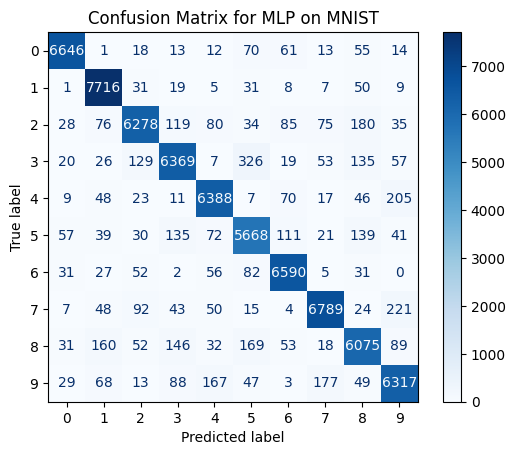

In [14]:
# Do a confusion matrix to see the performance of the model on each class
pred = model_dense.predict(X)
pred_classes = np.argmax(pred, axis=1)
cm = confusion_matrix(y, pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MLP on MNIST')
plt.show()

In [15]:
from sklearn.metrics import classification_report

# Print a classification report to see the precision, recall and f1-score for each class
report = classification_report(y, pred_classes, target_names=[str(i) for i in range(10)])
print(report)

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      6903
           1       0.94      0.98      0.96      7877
           2       0.93      0.90      0.92      6990
           3       0.92      0.89      0.90      7141
           4       0.93      0.94      0.93      6824
           5       0.88      0.90      0.89      6313
           6       0.94      0.96      0.95      6876
           7       0.95      0.93      0.94      7293
           8       0.90      0.89      0.89      6825
           9       0.90      0.91      0.91      6958

    accuracy                           0.93     70000
   macro avg       0.93      0.93      0.93     70000
weighted avg       0.93      0.93      0.93     70000



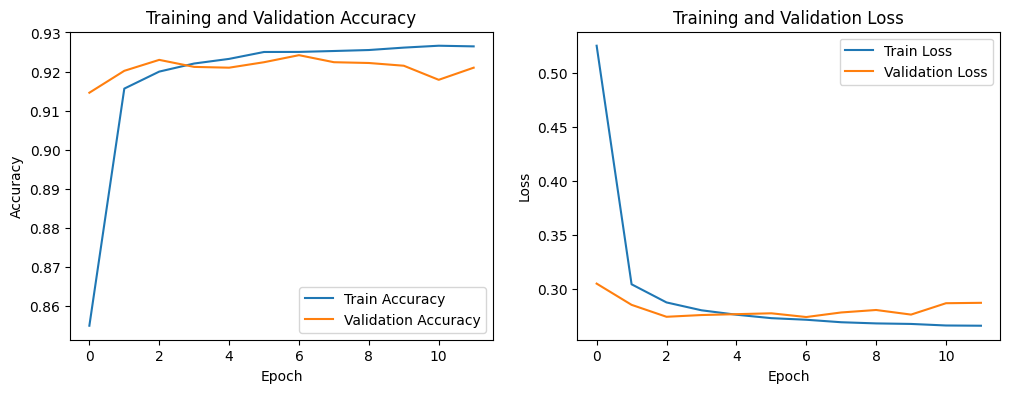

In [16]:
# Plot the training and validation accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

Compare the simple MLP to a SVM, or simple Logistic Regression model on the same dataset to see the difference in performance. You can use scikit-learn for this purpose.

In [17]:
from sklearn.svm import SVC

# Flatten the images for SVM
X_train_flat = X_train.reshape(X_train.shape[0], -1)[:500]
y_train_flat = y_train[:500]

# take only 500 example since it will take too much time to trina
X_test_flat = X_test.reshape(X_test.shape[0], -1)[:100]
y_test = y_test[:100]

# Train a simple SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_flat, y_train_flat)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
# Evaluate the SVM model
svm_pred = svm_model.predict(X_test_flat)

In [19]:
from sklearn.metrics import accuracy_score
svm_acc = accuracy_score(y_test, svm_pred)
print(f'SVM Test Accuracy: {svm_acc:.4f}')

SVM Test Accuracy: 0.9000


# Explore different activation functions

In [75]:
# reload the dataset to get the full test set
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize the pixel values to be between 0 and 1
# X_train = x_train.astype('float32') / 255.0
# X_test = x_test.astype('float32') / 255.0

In [77]:
model_2 = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

In [76]:
model_2.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

In [78]:
# compile the model
model_2.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

In [79]:
# fit the model
history_2 = model_2.fit(X_train, y_train,
                          epochs=50,
                          batch_size=BATCH_SIZE,
                          validation_data=(X_test, y_test),
                          callbacks=[early_stopping]
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8961 - loss: 0.3725 - val_accuracy: 0.9315 - val_loss: 0.2307
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9426 - loss: 0.2004 - val_accuracy: 0.9516 - val_loss: 0.1652
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9586 - loss: 0.1465 - val_accuracy: 0.9612 - val_loss: 0.1337
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9679 - loss: 0.1131 - val_accuracy: 0.9663 - val_loss: 0.1135
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9746 - loss: 0.0918 - val_accuracy: 0.9706 - val_loss: 0.0994
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9787 - loss: 0.0755 - val_accuracy: 0.9730 - val_loss: 0.0903
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9829 - loss: 0.0629 - val_accuracy: 0.9728 - val_loss: 0.0859
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9859 - loss: 0.0531 - val_accuracy: 0.

In [80]:
# validate the model on the test set
loss, acc = model_2.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy:{acc:.4f}')

Test accuracy:0.9783


In [81]:
# validate the model on the whole dataset
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)
loss, acc = model_2.evaluate(X, y, verbose=0)
print(f'Global accuracy:{acc:.4f}')

Global accuracy:0.9964


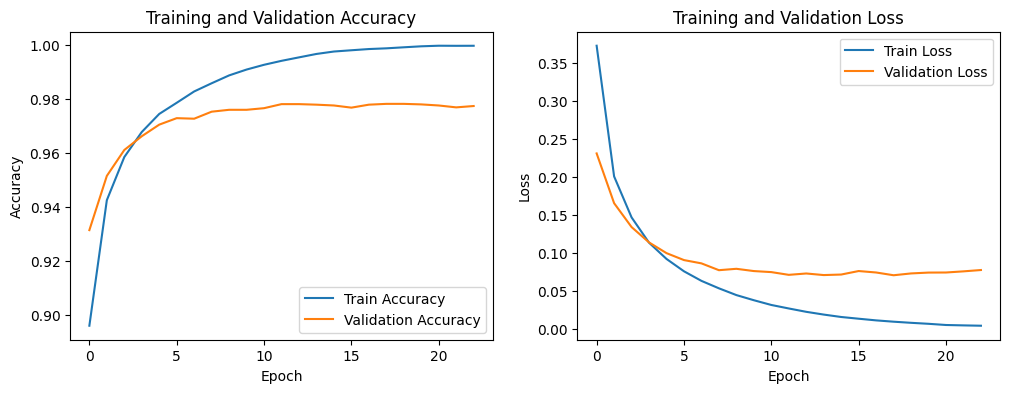

In [82]:
# plot the loss vs val_loss and acc vs val_acc
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

Just by using a different activation function, going from `relu` to `tanh`, we can see a significant difference in performance (92% vs 97% (99% one the whole dataset)). This is a good example of how important it is to experiment with different architectures and hyperparameters when training a neural network.